# RNN Text Classification with Different Embeddings

This notebook implements **RNN-based text classification** using:
1. Trainable (normal) word embeddings
2. Word2Vec Skip-gram
3. Word2Vec CBOW


## 1. Setup & Imports

In [1]:
print("Installing required packages...")

!pip install -U pip setuptools wheel Cython
!pip install gensim>=4.3.2
!pip install tensorflow>=2.10.0
!pip install scikit-learn>=1.0.0
!pip install matplotlib>=3.4.0
!pip install seaborn>=0.11.0
!pip install numpy>=1.21.0
!pip install pandas>=1.3.0

print("Installation complete.")

Installing required packages...
Installation complete.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import fetch_20newsgroups

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Embedding, Bidirectional, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from gensim.models import Word2Vec

np.random.seed(42)
tf.random.set_seed(42)



## 2. Load Dataset

In [3]:

categories = [
    'comp.graphics',
    'sci.med',
    'rec.sport.baseball',
    'talk.politics.misc'
]

train_data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

test_data = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

texts = list(train_data.data) + list(test_data.data)
labels = [train_data.target_names[i] for i in train_data.target] +          [test_data.target_names[i] for i in test_data.target]

print("Documents:", len(texts))
print("Classes:", categories)


Documents: 3732
Classes: ['comp.graphics', 'sci.med', 'rec.sport.baseball', 'talk.politics.misc']


## 3. Text Preprocessing (matched)

Encoded classes: ['comp.graphics' 'rec.sport.baseball' 'sci.med' 'talk.politics.misc']


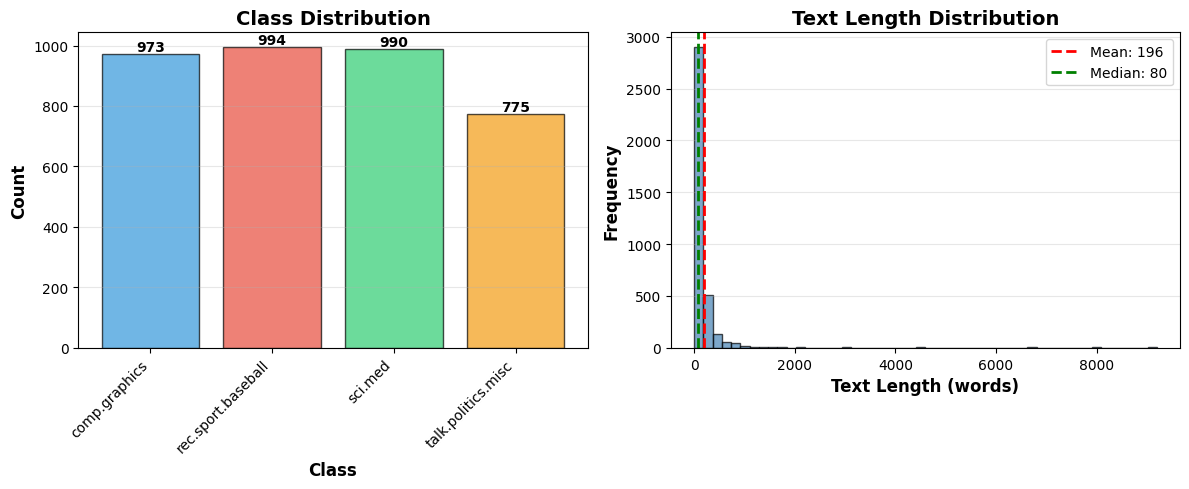

In [4]:

def preprocess_text(texts):
    processed = []
    for text in texts:
        text = text.lower()
        text = ' '.join(text.split())
        processed.append(text)
    return processed

texts = preprocess_text(texts)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

print("Encoded classes:", label_encoder.classes_)

# Data exploration
label_dist = {label_encoder.classes_[i]: list(y).count(i) for i in range(len(label_encoder.classes_))}
text_lengths = [len(text.split()) for text in texts]

# Plot data distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(label_dist.keys(), label_dist.values(), color=colors, alpha=0.7, edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(text_lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(text_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(text_lengths):.0f}')
plt.axvline(np.median(text_lengths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(text_lengths):.0f}')
plt.xlabel('Text Length (words)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Text Length Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Tokenization & Padding

In [5]:

MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Vocabulary size:", len(tokenizer.word_index))
print("Input shape:", X.shape)


Vocabulary size: 36779
Input shape: (3732, 100)


## 5. Train-Test Split

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (2985, 100)
Test: (747, 100)


## 6. Model Builder (RNN)

In [7]:

def build_rnn_model(embedding_matrix=None, embedding_dim=100, rnn_units=128, num_classes=4):
    model = Sequential()

    if embedding_matrix is not None:
        model.add(Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False
        ))
    else:
        model.add(Embedding(
            input_dim=min(len(tokenizer.word_index) + 1, MAX_WORDS),
            output_dim=embedding_dim,
            input_length=MAX_LEN
        ))

    model.add(SpatialDropout1D(0.2))
    model.add(Bidirectional(SimpleRNN(rnn_units)))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Helper functions for visualization
def plot_training_history(history, embedding_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train', marker='o', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s', linewidth=2)
    axes[0].set_title(f'Model Accuracy - {embedding_name}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train', marker='o', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', marker='s', linewidth=2)
    axes[1].set_title(f'Model Loss - {embedding_name}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, embedding_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {embedding_name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

def evaluate_and_plot(model, X_test, y_test, embedding_name):
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\nEvaluation Results - {embedding_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(cm, embedding_name)

    return accuracy, f1

print("Helper functions defined")

Helper functions defined


## 7. Experiment 1: Trainable Embeddings

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.2674 - loss: 1.4124 - val_accuracy: 0.2831 - val_loss: 1.4033
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4268 - loss: 1.2857 - val_accuracy: 0.3417 - val_loss: 1.3551
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6132 - loss: 1.0763 - val_accuracy: 0.3250 - val_loss: 1.3622
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7416 - loss: 0.8794 - val_accuracy: 0.3534 - val_loss: 1.3830
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8466 - loss: 0.5570 - val_accuracy: 0.3752 - val_loss: 1.4785


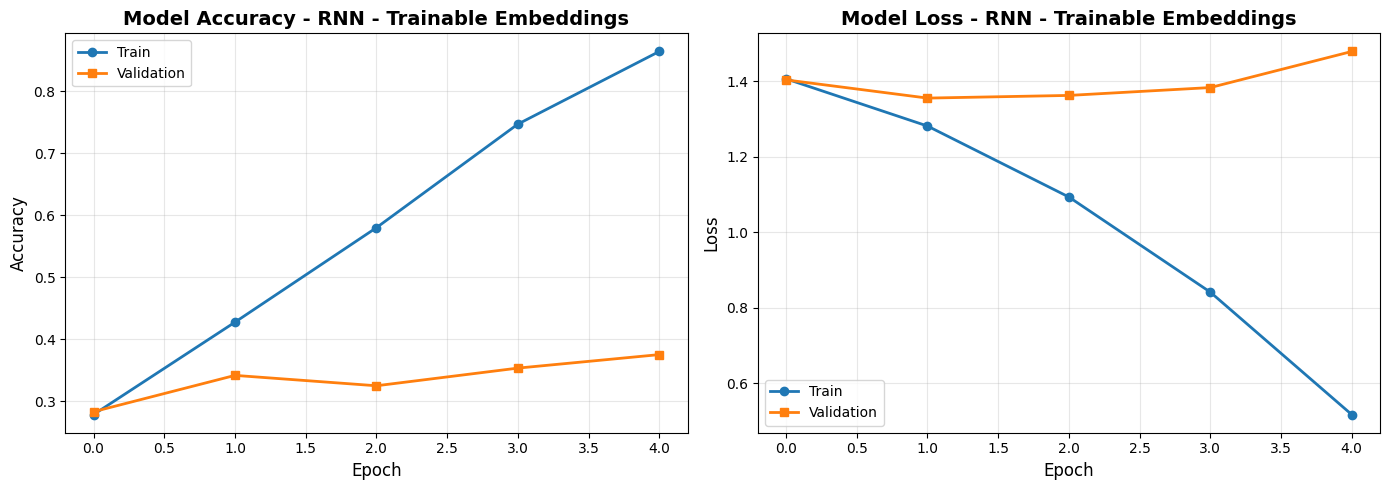


Evaluation Results - RNN - Trainable Embeddings
Accuracy: 0.3494
F1-Score: 0.3423

Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.41      0.39      0.40       195
rec.sport.baseball       0.33      0.48      0.39       199
           sci.med       0.29      0.30      0.29       198
talk.politics.misc       0.46      0.19      0.27       155

          accuracy                           0.35       747
         macro avg       0.37      0.34      0.34       747
      weighted avg       0.37      0.35      0.34       747



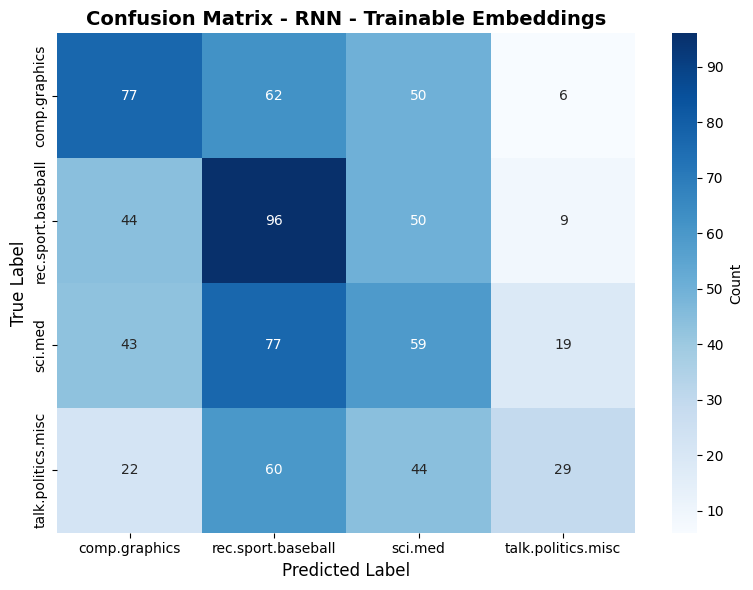

In [9]:

model_trainable = build_rnn_model(num_classes=len(label_encoder.classes_))
model_trainable.summary()

history_trainable = model_trainable.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)


# Plot training history and evaluate

plot_training_history(history_trainable, "RNN - Trainable Embeddings")
accuracy_trainable, f1_trainable = evaluate_and_plot(model_trainable, X_test, y_test, "RNN - Trainable Embeddings")

## 8. Experiment 2: Word2Vec Skip-gram

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.3028 - loss: 1.4884 - val_accuracy: 0.4489 - val_loss: 1.2194
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4818 - loss: 1.1638 - val_accuracy: 0.5310 - val_loss: 1.0961
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5637 - loss: 1.0439 - val_accuracy: 0.5963 - val_loss: 0.9639
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5641 - loss: 1.0415 - val_accuracy: 0.5444 - val_loss: 1.0399
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5615 - loss: 1.0175 - val_accuracy: 0.5695 - val_loss: 1.0616
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6201 - loss: 0.9363 - val_accuracy: 0.6616 - val_loss: 0.8528
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6510 - loss: 0.8674 - val_accuracy: 0.6499 - val_loss: 0.8521
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6620 - loss: 0.8459 - val_accuracy: 0.6013 - 

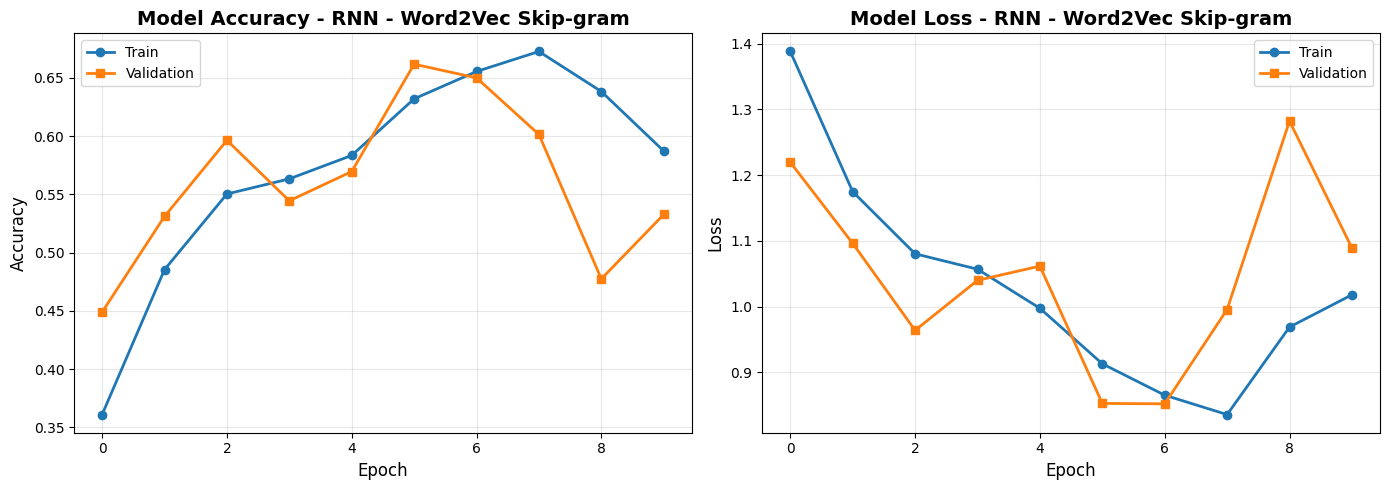


Evaluation Results - RNN - Word2Vec Skip-gram
Accuracy: 0.6386
F1-Score: 0.6169

Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.65      0.90      0.75       195
rec.sport.baseball       0.70      0.82      0.76       199
           sci.med       0.56      0.41      0.47       198
talk.politics.misc       0.58      0.37      0.45       155

          accuracy                           0.64       747
         macro avg       0.62      0.62      0.61       747
      weighted avg       0.63      0.64      0.62       747



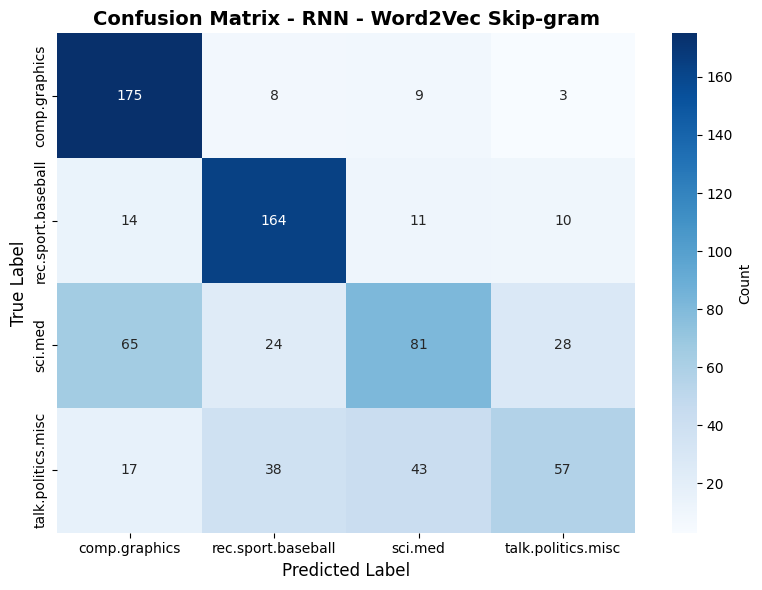

In [10]:

tokenized_texts = [text.split() for text in texts]

w2v_skip = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=10
)

vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS)
embedding_matrix_skip = np.zeros((vocab_size, 100))

for word, idx in tokenizer.word_index.items():
    if idx < MAX_WORDS and word in w2v_skip.wv:
        embedding_matrix_skip[idx] = w2v_skip.wv[word]

model_skip = build_rnn_model(
    embedding_matrix=embedding_matrix_skip,
    num_classes=len(label_encoder.classes_)
)

history_skip = model_skip.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)


# Plot training history and evaluate

plot_training_history(history_skip, "RNN - Word2Vec Skip-gram")
accuracy_skip, f1_skip = evaluate_and_plot(model_skip, X_test, y_test, "RNN - Word2Vec Skip-gram")

## 9. Experiment 3: Word2Vec CBOW

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.2694 - loss: 1.6543 - val_accuracy: 0.3769 - val_loss: 1.3429
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3657 - loss: 1.3934 - val_accuracy: 0.4070 - val_loss: 1.2717
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4177 - loss: 1.3160 - val_accuracy: 0.3886 - val_loss: 1.3291
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4024 - loss: 1.3442 - val_accuracy: 0.3936 - val_loss: 1.3016
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3988 - loss: 1.3199 - val_accuracy: 0.4489 - val_loss: 1.2225
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4461 - loss: 1.2424 - val_accuracy: 0.4472 - val_loss: 1.2310
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4399 - loss: 1.2201 - val_accuracy: 0.4539 - val_loss: 1.2205
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4649 - loss: 1.1812 - val_accuracy: 0.4724 - val_loss: 1

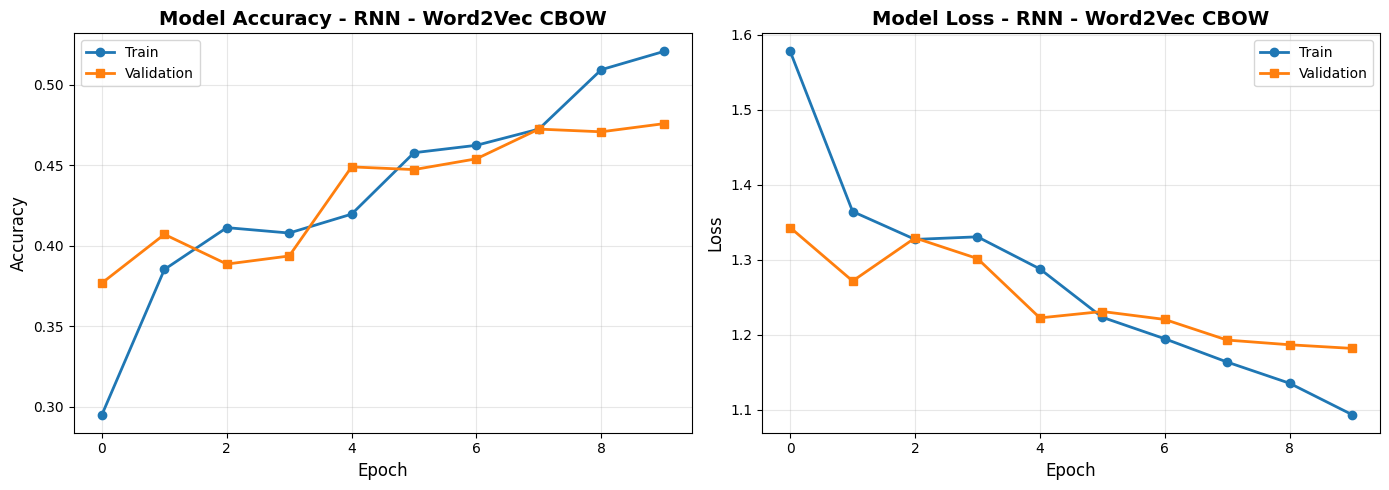


Evaluation Results - RNN - Word2Vec CBOW
Accuracy: 0.5020
F1-Score: 0.4875

Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.63      0.70      0.67       195
rec.sport.baseball       0.47      0.65      0.55       199
           sci.med       0.47      0.29      0.36       198
talk.politics.misc       0.39      0.33      0.36       155

          accuracy                           0.50       747
         macro avg       0.49      0.49      0.48       747
      weighted avg       0.49      0.50      0.49       747



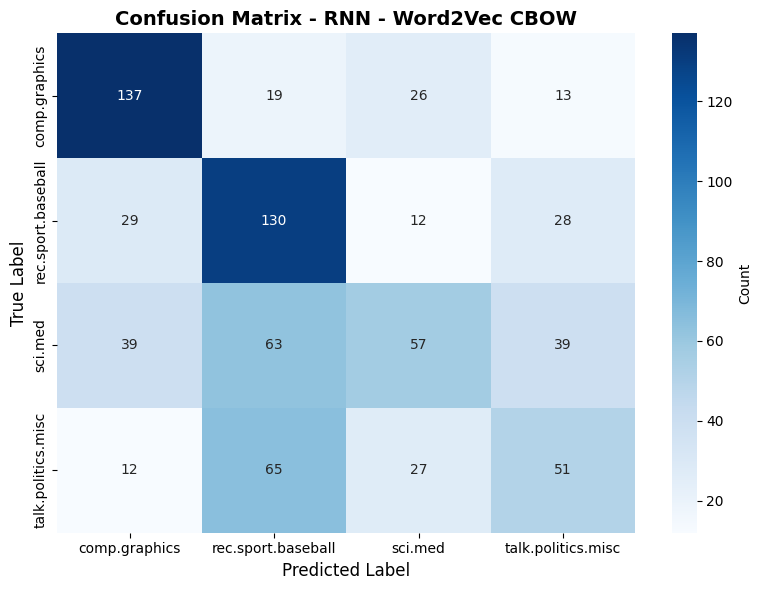

In [11]:

w2v_cbow = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=1,
    sg=0,
    epochs=10
)

embedding_matrix_cbow = np.zeros((vocab_size, 100))

for word, idx in tokenizer.word_index.items():
    if idx < MAX_WORDS and word in w2v_cbow.wv:
        embedding_matrix_cbow[idx] = w2v_cbow.wv[word]

model_cbow = build_rnn_model(
    embedding_matrix=embedding_matrix_cbow,
    num_classes=len(label_encoder.classes_)
)

history_cbow = model_cbow.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)


# Plot training history and evaluate

plot_training_history(history_cbow, "RNN - Word2Vec CBOW")
accuracy_cbow, f1_cbow = evaluate_and_plot(model_cbow, X_test, y_test, "RNN - Word2Vec CBOW")

## 10. Final Evaluation

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

RNN – Trainable Embedding
Accuracy: 0.3493975903614458
                    precision    recall  f1-score   support

     comp.graphics       0.41      0.39      0.40       195
rec.sport.baseball       0.33      0.48      0.39       199
           sci.med       0.29      0.30      0.29       198
talk.politics.misc       0.46      0.19      0.27       155

          accuracy                           0.35       747
         macro avg       0.37      0.34      0.34       747
      weighted avg       0.37      0.35      0.34       747

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

RNN – Word2Vec Skip-gram
Accuracy: 0.6385542168674698
                    precision    recall  f1-score   support

     comp.graphics       0.65      0.90      0.75       195
rec.sport.baseball       0.70      0.82      0.76       199
           sci.med       0.56      0.41      0.47       198
talk.politics.misc       0.58      0.37      0.45       155

          accuracy       

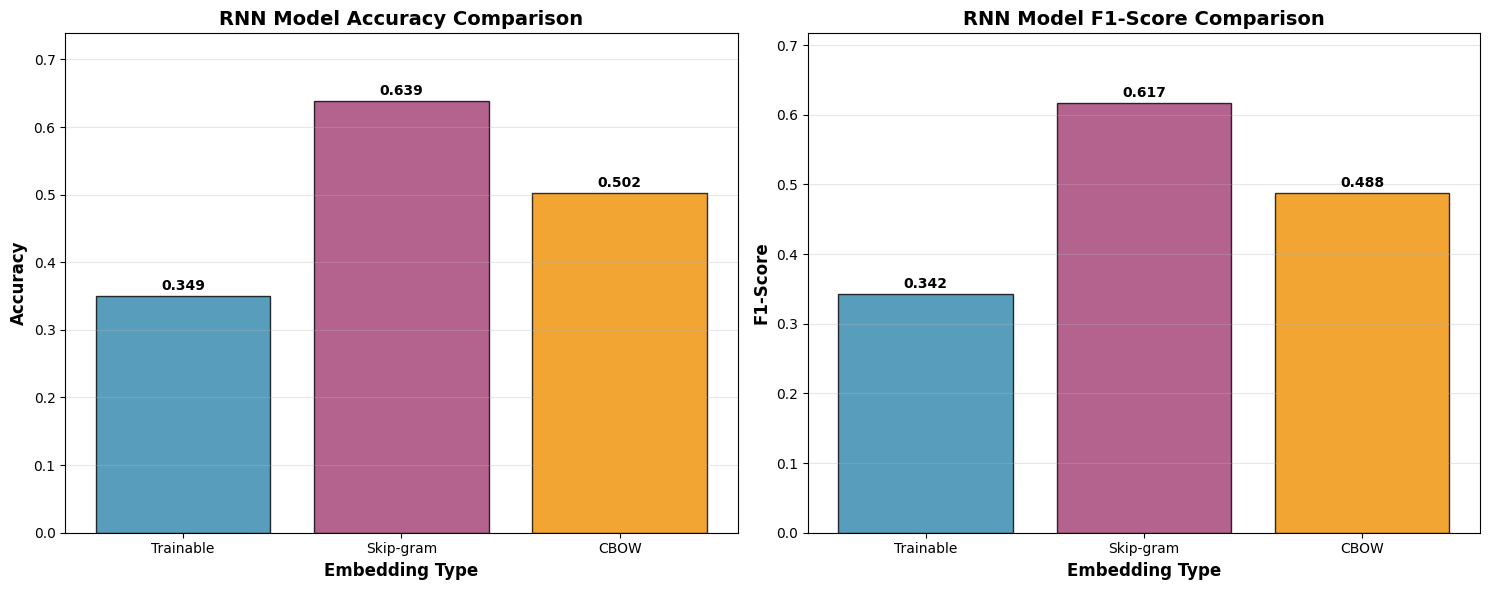

In [12]:

def evaluate(model, name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

evaluate(model_trainable, "RNN – Trainable Embedding")
evaluate(model_skip, "RNN – Word2Vec Skip-gram")
evaluate(model_cbow, "RNN – Word2Vec CBOW")


# Summary visualization
embedding_types = ['Trainable', 'Skip-gram', 'CBOW']
accuracies = [accuracy_trainable, accuracy_skip, accuracy_cbow]
f1_scores = [f1_trainable, f1_skip, f1_cbow]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars1 = ax1.bar(embedding_types, accuracies, color=colors, alpha=0.8, edgecolor='black')
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{acc:.3f}',
            ha='center', va='bottom', fontweight='bold')
ax1.set_title('RNN Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Embedding Type', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(accuracies) + 0.1)

# F1-Score comparison
bars2 = ax2.bar(embedding_types, f1_scores, color=colors, alpha=0.8, edgecolor='black')
for bar, f1 in zip(bars2, f1_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{f1:.3f}',
            ha='center', va='bottom', fontweight='bold')
ax2.set_title('RNN Model F1-Score Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Embedding Type', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(f1_scores) + 0.1)

plt.tight_layout()
plt.show()

## 11.References

**References**

Elman, J. L. (1990). Finding structure in time. Cognitive Science, 14(2), 179–211.

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural Computation, 9(8), 1735–1780.

Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. arXiv preprint arXiv:1301.3781.

Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). Distributed representations of words and phrases and their compositionality. Advances in Neural Information Processing Systems, 26.

Kim, Y. (2014). Convolutional neural networks for sentence classification. arXiv preprint arXiv:1408.5882.

Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: Global vectors for word representation. In Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP) (pp. 1532–1543).